# Sparse identification of the Ornstein–Uhlenbeck Fokker–Planck equation

## Aim

This notebook establishes the baseline comparison between pointwise SINDy
and Weak SINDy.

The same Ornstein–Uhlenbeck equation is identified from:

1. the analytical density $\rho^{\mathrm{exact}}$;
2. the finite-difference density $\rho^{\mathrm{FD}}$;
3. an Euler–Maruyama histogram density $\rho^{\mathrm{EM}}$.

The purpose is to determine which part of the identification pipeline fails
as the density data become less smooth.


The notation used throughout is:

- `rho_exact`: analytical density $\rho^{\mathrm{exact}}$;
- `rho_t_exact`: analytical derivative $\rho_t^{\mathrm{exact}}$, used only as the ground-truth reference;
- `rho_t`: numerical time derivative computed from `rho_exact`, used as the SINDy target;
- `rho_t_hat`: SINDy reconstruction $\widehat{\rho_t}$;
- `rho_fd`: FD-generated density $\rho^{\mathrm{FD}}$;
- `rho_t_fd`: numerical time derivative computed from `rho_fd`, used as the FD-data SINDy target;
- `rho_t_hat_fd`: FD-data SINDy reconstruction $\widehat{\rho_t}^{\,\mathrm{FD}}$；
- `rho_em`: EM-generated density $\rho^{\mathrm{EM}}$;
- `rho_t_em`: numerical time derivative computed from `rho_em`, used as the EM-data SINDy target;
- `rho_t_hat_em`: EM-data SINDy reconstruction $\widehat{\rho_t}^{\,\mathrm{EM}}$；



In [1]:
# ============================================================
# Imports
# ============================================================

import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps

from IPython.display import display


In [2]:
# ============================================================
# Shared OU parameters and helper functions
# ============================================================

kappa = 1.0
D = 1.0

# Non-stationary Gaussian initial distribution
m0 = -2.0
s0 = 0.5

# Space-time domain
x_L = -5.0
x_R = 5.0
T_final = 3.0


def exact_ou_moments(t_grid, kappa, D, m0, s0):
    """Return the exact OU mean, variance and their time derivatives."""

    mean = m0 * np.exp(-kappa * t_grid)

    variance = (
        s0**2 * np.exp(-2.0 * kappa * t_grid)
        + (D / kappa) * (
            1.0 - np.exp(-2.0 * kappa * t_grid)
        )
    )

    mean_t = -kappa * mean
    variance_t = -2.0 * kappa * variance + 2.0 * D

    return mean, variance, mean_t, variance_t


def exact_ou_density(x_grid, t_grid, kappa, D, m0, s0):
    """Exact density of dX_t = -kappa X_t dt + sqrt(2D) dW_t."""

    mean, variance, _, _ = exact_ou_moments(
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    return (
        np.exp(
            -0.5 * (x_grid - mean)**2 / variance
        )
        / np.sqrt(2.0 * np.pi * variance)
    )


def exact_ou_time_derivative(x_grid, t_grid, kappa, D, m0, s0):
    """Analytical time derivative of the exact OU density."""

    mean, variance, mean_t, variance_t = exact_ou_moments(
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    density = exact_ou_density(
        x_grid,
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    return density * (
        mean_t * (x_grid - mean) / variance
        + variance_t
        / (2.0 * variance**2)
        * (
            (x_grid - mean)**2 - variance
        )
    )


def relative_l2_error(approximation, reference):
    """Relative Euclidean L2 error after flattening both arrays."""

    approximation = np.asarray(approximation).ravel()
    reference = np.asarray(reference).ravel()

    reference_norm = np.linalg.norm(reference)

    if reference_norm == 0.0:
        raise ZeroDivisionError(
            "The reference array has zero L2 norm."
        )

    return (
        np.linalg.norm(approximation - reference)
        / reference_norm
    )


def print_identified_equation(feature_names, coefficients, tolerance=1e-10):
    """Print a readable sparse PDE from identified coefficients."""

    identified_terms = []

    for name, coefficient in zip(feature_names, coefficients):
        if abs(coefficient) > tolerance:
            identified_terms.append(
                f"({coefficient:+.6f}) {name}"
            )

    equation = " ".join(identified_terms)

    print("True Fokker–Planck equation:")
    print(
        f"rho_t = {kappa:.6f} d_x(x rho)"
        f" + {D:.6f} rho_xx"
    )

    print()
    print("Identified Fokker–Planck equation:")
    print(f"rho_t = {equation}")


def plot_error_heatmap(t_grid, x_grid, error_field, title, colorbar_label="Error"):
    """Plot a signed error field with symmetric colour limits."""

    max_abs_error = np.max(np.abs(error_field))
    max_abs_error = max(max_abs_error, np.finfo(float).eps)

    fig, ax = plt.subplots(figsize=(8, 5))

    plot = ax.pcolormesh(
        t_grid,
        x_grid,
        error_field,
        shading="auto",
        vmin=-max_abs_error,
        vmax=max_abs_error,
        cmap="coolwarm",
    )

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$x$")
    ax.set_title(title)

    fig.colorbar(
        plot,
        ax=ax,
        label=colorbar_label,
    )

    plt.tight_layout()
    plt.show()


# 1. Exact OU density

Here the input density is analytical, but the SINDy target is still obtained by numerical differentiation:

$$
\rho^{\mathrm{exact}}
\xrightarrow{\text{numerical }\partial_t}
\rho_t
\xrightarrow{\text{SINDy}}
\widehat{\rho_t}.
$$

The analytical derivative $\rho_t^{\mathrm{exact}}$ is retained separately as the validation reference.


In [3]:
# ============================================================
# 1.1 Exact-data space-time grid
# ============================================================

Nx_exact = 400
Nt_exact = 600

x = np.linspace(x_L, x_R, Nx_exact + 1)
t = np.linspace(0.0, T_final, Nt_exact + 1)

dx = x[1] - x[0]
dt = t[1] - t[0]

# X[i, j] = x[i], Time[i, j] = t[j]
X, Time = np.meshgrid(
    x,
    t,
    indexing="ij",
)

print("x shape:   ", x.shape)
print("t shape:   ", t.shape)
print("grid shape:", X.shape)
print("dx:        ", dx)
print("dt:        ", dt)


x shape:    (401,)
t shape:    (601,)
grid shape: (401, 601)
dx:         0.025000000000000355
dt:         0.005


In [4]:
# ============================================================
# 1.2 Analytical density and analytical time derivative
# ============================================================

rho_exact = exact_ou_density(
    X,
    Time,
    kappa,
    D,
    m0,
    s0,
)

# Ground truth used for validation only
rho_t_exact = exact_ou_time_derivative(
    X,
    Time,
    kappa,
    D,
    m0,
    s0,
)

print("rho_exact shape: ", rho_exact.shape)
print("rho_t_exact shape:", rho_t_exact.shape)


rho_exact shape:  (401, 601)
rho_t_exact shape: (401, 601)


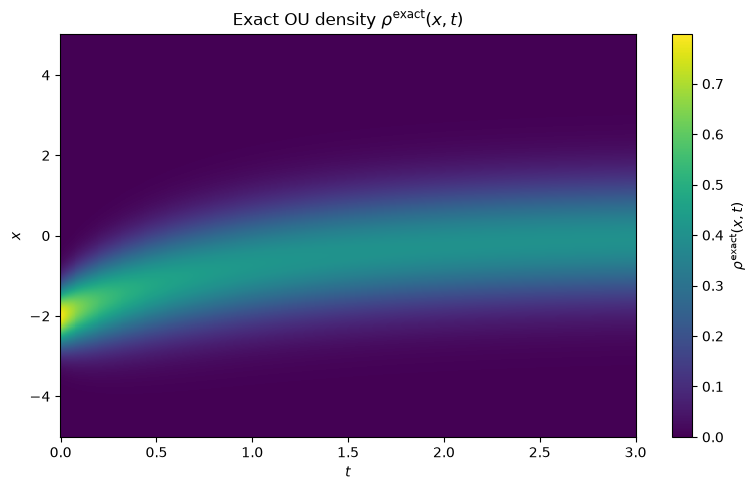

In [5]:
# ============================================================
# 1.3 Visualise the exact density data
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

plot = ax.pcolormesh(
    t,
    x,
    rho_exact,
    shading="auto",
)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x$")
ax.set_title(
    r"Exact OU density $\rho^{\mathrm{exact}}(x,t)$"
)

fig.colorbar(
    plot,
    ax=ax,
    label=r"$\rho^{\mathrm{exact}}(x,t)$",
)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 1.4 Numerical derivatives computed from rho_exact
# ============================================================

Dt_exact_data = ps.FiniteDifference(
    d=1,
    axis=1,
    order=4,
)

Dx_exact_data = ps.FiniteDifference(
    d=1,
    axis=0,
    order=4,
)

Dxx_exact_data = ps.FiniteDifference(
    d=2,
    axis=0,
    order=4,
)

Dxxx_exact_data = ps.FiniteDifference(
    d=3,
    axis=0,
    order=4,
)

# Numerical time derivative used as the SINDy target
rho_t = Dt_exact_data(rho_exact, t)

# Numerical spatial derivatives used to construct the library
rho_x = Dx_exact_data(rho_exact, x)
rho_xx = Dxx_exact_data(rho_exact, x)
rho_xxx = Dxxx_exact_data(rho_exact, x)

# Conservative drift candidates
d_x_xrho = Dx_exact_data(X * rho_exact, x)
d_x_x2rho = Dx_exact_data(X**2 * rho_exact, x)

print("rho_t shape:", rho_t.shape)


rho_t shape: (401, 601)


In [7]:
# ============================================================
# 1.5 Candidate library for exact-density data
# ============================================================

candidate_fields = {
    "rho": rho_exact,
    "rho_x": rho_x,
    "d_x(x rho)": d_x_xrho,
    "d_x(x^2 rho)": d_x_x2rho,
    "rho_xx": rho_xx,
    "rho_xxx": rho_xxx,
}

feature_names = list(candidate_fields.keys())

true_coefficients = np.array([
    0.0,       # rho
    0.0,       # rho_x
    kappa,     # d_x(x rho)
    0.0,       # d_x(x^2 rho)
    D,         # rho_xx
    0.0,       # rho_xxx
])

print("Candidate terms:")
for name in feature_names:
    print("  ", name)


Candidate terms:
   rho
   rho_x
   d_x(x rho)
   d_x(x^2 rho)
   rho_xx
   rho_xxx


In [8]:
# ============================================================
# 1.6 Interior fitting region and sparse regression
# ============================================================

# Fourth-order finite differences require boundary care.
# These slices are used consistently for fitting and all errors.
space_slice = slice(4, -4)
time_slice = slice(2, -2)

Theta = np.column_stack([
    field[space_slice, time_slice].ravel()
    for field in candidate_fields.values()
])

rho_t_vector = rho_t[
    space_slice,
    time_slice,
].ravel().reshape(-1, 1)

optimizer_exact = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,
    max_iter=50,
    normalize_columns=True,
)

optimizer_exact.fit(
    Theta,
    rho_t_vector,
)

coefficients = optimizer_exact.coef_.reshape(-1)

print("Theta shape:      ", Theta.shape)
print("rho_t target shape:", rho_t_vector.shape)


Theta shape:       (234621, 6)
rho_t target shape: (234621, 1)


In [9]:
# ============================================================
# 1.7 Identified coefficients and PDE
# ============================================================

coefficient_table = pd.DataFrame({
    "Candidate term": feature_names,
    "Identified coefficient": coefficients,
    "True coefficient": true_coefficients,
    "Absolute error": np.abs(
        coefficients - true_coefficients
    ),
})

display(
    coefficient_table.style.format({
        "Identified coefficient": "{:.6f}",
        "True coefficient": "{:.6f}",
        "Absolute error": "{:.3e}",
    })
)

print_identified_equation(
    feature_names,
    coefficients,
)


,Candidate term,Identified coefficient,True coefficient,Absolute error
0,rho,0.000000,0.000000,0.000e+00
1,rho_x,0.000000,0.000000,0.000e+00
2,d_x(x rho),1.000000,1.000000,2.468e-07
3,d_x(x^2 rho),0.000000,0.000000,0.000e+00
4,rho_xx,1.000000,1.000000,2.066e-07
5,rho_xxx,0.000000,0.000000,0.000e+00


True Fokker–Planck equation:
rho_t = 1.000000 d_x(x rho) + 1.000000 rho_xx

Identified Fokker–Planck equation:
rho_t = (+1.000000) d_x(x rho) (+1.000000) rho_xx


In [10]:
# ============================================================
# 1.8 Reconstruct the identified derivative rho_t_hat
# ============================================================

rho_t_hat = np.zeros_like(rho_t)

for coefficient, field in zip(
    coefficients,
    candidate_fields.values(),
):
    rho_t_hat += coefficient * field

print(r"Constructed rho_t_hat = sum_j coefficient_j * candidate_field_j")
print("rho_t_hat shape:", rho_t_hat.shape)


Constructed rho_t_hat = sum_j coefficient_j * candidate_field_j
rho_t_hat shape: (401, 601)


In [11]:
# ============================================================
# 1.9 Three errors for exact-density identification
# ============================================================

rho_t_interior = rho_t[
    space_slice,
    time_slice,
]

rho_t_exact_interior = rho_t_exact[
    space_slice,
    time_slice,
]

rho_t_hat_interior = rho_t_hat[
    space_slice,
    time_slice,
]

# 1. Numerical differentiation error:
#    rho_t is computed numerically from rho_exact.
error_exact_differentiation = relative_l2_error(
    rho_t_interior,
    rho_t_exact_interior,
)

# 2. SINDy fitting error relative to its actual numerical target.
error_exact_fit = relative_l2_error(
    rho_t_hat_interior,
    rho_t_interior,
)

# 3. End-to-end identification error relative to exact dynamics.
error_exact_total = relative_l2_error(
    rho_t_hat_interior,
    rho_t_exact_interior,
)

exact_error_table = pd.DataFrame({
    "Comparison": [
        "Numerical derivative vs analytical derivative",
        "SINDy derivative vs numerical target",
        "SINDy derivative vs analytical derivative",
    ],
    "Mathematical quantity": [
        r"rho_t - rho_t_exact",
        r"rho_t_hat - rho_t",
        r"rho_t_hat - rho_t_exact",
    ],
    "Relative L2 error": [
        error_exact_differentiation,
        error_exact_fit,
        error_exact_total,
    ],
    "Meaning": [
        "Numerical time-differentiation error",
        "Sparse-regression fitting error",
        "Total identification error",
    ],
})

display(
    exact_error_table.style.format({
        "Relative L2 error": "{:.6e}",
    })
)


,Comparison,Mathematical quantity,Relative L2 error,Meaning
0,Numerical derivative vs analytical derivative,rho_t - rho_t_exact,7.902051e-07,Numerical time-differentiation error
1,SINDy derivative vs numerical target,rho_t_hat - rho_t,6.226625e-07,Sparse-regression fitting error
2,SINDy derivative vs analytical derivative,rho_t_hat - rho_t_exact,5.738601e-07,Total identification error


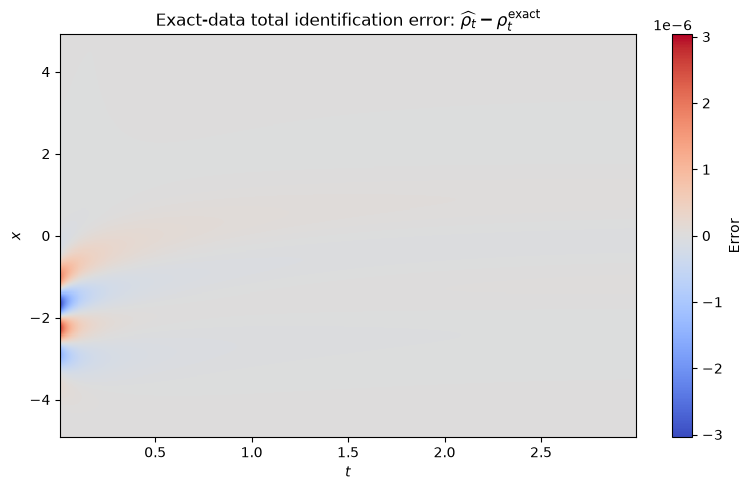

In [12]:
# ============================================================
# 1.10 Exact-data heatmap: total identification error
# ============================================================

# Error convention used throughout:
# prediction minus reference
error_total_exact_field = (
    rho_t_hat_interior
    - rho_t_exact_interior
)

plot_error_heatmap(
    t[time_slice],
    x[space_slice],
    error_total_exact_field,
    title=(
        r"Exact-data total identification error: "
        r"$\widehat{\rho_t}-\rho_t^{\mathrm{exact}}$"
    ),
)


# 2. FD OU density

For FD-generated data, the complete pipeline is

$$
\rho^{\mathrm{FD}}
\xrightarrow{\text{numerical }\partial_t}
\rho_t^{\mathrm{FD}}
\xrightarrow{\text{SINDy}}
\widehat{\rho_t}^{\,\mathrm{FD}}.
$$

The exact density and exact derivative are recomputed independently on the FD space-time grid. Therefore, this section does not depend on variables left over from the exact-data section.


In [13]:
# ============================================================
# 2.1 Import the reusable FD solver
# ============================================================

import ou_fd

importlib.reload(ou_fd)
solve_ou_fd = ou_fd.solve_ou_fd


In [14]:
# ============================================================
# 2.2 FD resolution and saved data times
# ============================================================

# Number of spatial intervals in the FD solver
Nx_fd = 400

# Number of saved time intervals supplied to SINDy
Nt_data_fd = 600

# Number of internal Forward-Euler steps in the FD solver
Nt_internal_fd = 24000

if Nt_internal_fd % Nt_data_fd != 0:
    raise ValueError(
        "Nt_internal_fd must be divisible by Nt_data_fd "
        "so every saved time lies on the internal FD time grid."
    )

save_times_fd = np.linspace(
    0.0,
    T_final,
    Nt_data_fd + 1,
)

print("Number of saved times:      ", save_times_fd.size)
print("Internal FD time step:      ", T_final / Nt_internal_fd)
print("Saved-data time separation:", T_final / Nt_data_fd)


Number of saved times:       601
Internal FD time step:       0.000125
Saved-data time separation: 0.005


In [15]:
# ============================================================
# 2.3 Generate FD density snapshots
# ============================================================

fd_solution = solve_ou_fd(
    Nx=Nx_fd,
    Nt=Nt_internal_fd,
    k=kappa,
    D=D,
    x_L=x_L,
    x_R=x_R,
    m0=m0,
    s0=s0,
    T=T_final,
    save_times=save_times_fd,
    track_history=False,
)


In [16]:
# ============================================================
# 2.4 Convert the FD snapshots into rho_fd(x,t)
# ============================================================

x_fd = np.asarray(fd_solution["x"])

t_fd = np.array(
    sorted(fd_solution["snapshots"].keys())
)

rho_fd = np.column_stack([
    fd_solution["snapshots"][saved_time]
    for saved_time in t_fd
])

dx_fd = float(fd_solution["dx"])
dt_internal_fd = float(fd_solution["dt"])
dt_data_fd = t_fd[1] - t_fd[0]

X_fd, Time_fd = np.meshgrid(
    x_fd,
    t_fd,
    indexing="ij",
)

if rho_fd.shape != X_fd.shape:
    raise ValueError(
        f"rho_fd has shape {rho_fd.shape}, "
        f"but the FD coordinate grid has shape {X_fd.shape}."
    )

# Independent analytical references evaluated on the FD grid
rho_exact_fd_grid = exact_ou_density(
    X_fd,
    Time_fd,
    kappa,
    D,
    m0,
    s0,
)

rho_t_exact_fd_grid = exact_ou_time_derivative(
    X_fd,
    Time_fd,
    kappa,
    D,
    m0,
    s0,
)

print("x_fd shape:                ", x_fd.shape)
print("t_fd shape:                ", t_fd.shape)
print("rho_fd shape:              ", rho_fd.shape)
print("rho_t_exact_fd_grid shape: ", rho_t_exact_fd_grid.shape)
print("dx_fd:                     ", dx_fd)
print("dt_internal_fd:            ", dt_internal_fd)
print("dt_data_fd:                ", dt_data_fd)


x_fd shape:                 (401,)
t_fd shape:                 (601,)
rho_fd shape:               (401, 601)
rho_t_exact_fd_grid shape:  (401, 601)
dx_fd:                      0.025000000000000355
dt_internal_fd:             0.000125
dt_data_fd:                 0.005


Minimum mass inside domain: 0.9999999990058279
Maximum mass inside domain: 1.0000005106467649
Minimum density:            2.1932131187779425e-43
Maximum density:            0.7978845608028654


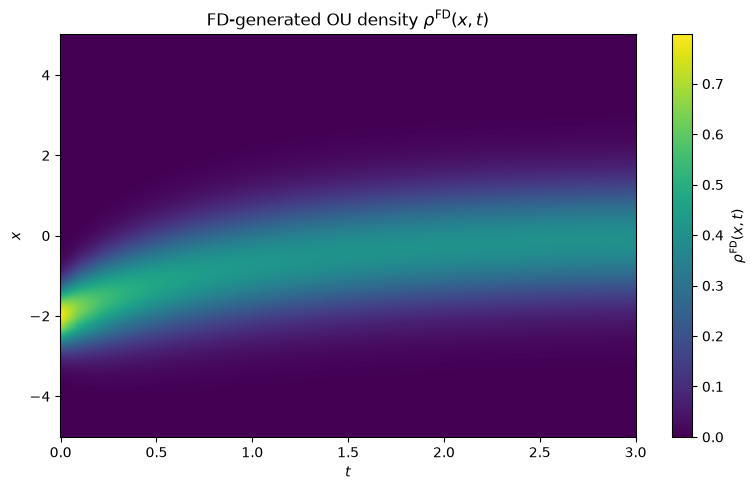

In [17]:
# ============================================================
# 2.5 Check the FD-generated density
# ============================================================

mass_fd = np.trapezoid(
    rho_fd,
    x=x_fd,
    axis=0,
)

print("Minimum mass inside domain:", mass_fd.min())
print("Maximum mass inside domain:", mass_fd.max())
print("Minimum density:           ", rho_fd.min())
print("Maximum density:           ", rho_fd.max())

fig, ax = plt.subplots(figsize=(8, 5))

plot = ax.pcolormesh(
    t_fd,
    x_fd,
    rho_fd,
    shading="auto",
)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x$")
ax.set_title(r"FD-generated OU density $\rho^{\mathrm{FD}}(x,t)$")

fig.colorbar(
    plot,
    ax=ax,
    label=r"$\rho^{\mathrm{FD}}(x,t)$",
)

plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# 2.6 Numerical derivatives computed from rho_fd
# ============================================================

Dt_fd_data = ps.FiniteDifference(
    d=1,
    axis=1,
    order=4,
)

Dx_fd_data = ps.FiniteDifference(
    d=1,
    axis=0,
    order=4,
)

Dxx_fd_data = ps.FiniteDifference(
    d=2,
    axis=0,
    order=4,
)

Dxxx_fd_data = ps.FiniteDifference(
    d=3,
    axis=0,
    order=4,
)

# Numerical time derivative used as the FD-data SINDy target
rho_t_fd = Dt_fd_data(rho_fd, t_fd)

# Numerical spatial derivatives used to construct the FD library
rho_x_fd = Dx_fd_data(rho_fd, x_fd)
rho_xx_fd = Dxx_fd_data(rho_fd, x_fd)
rho_xxx_fd = Dxxx_fd_data(rho_fd, x_fd)

# Conservative drift candidates
d_x_xrho_fd = Dx_fd_data(X_fd * rho_fd, x_fd)
d_x_x2rho_fd = Dx_fd_data(X_fd**2 * rho_fd, x_fd)

print("rho_t_fd shape:", rho_t_fd.shape)


rho_t_fd shape: (401, 601)


In [19]:
# ============================================================
# 2.7 Candidate library for FD-density data
# ============================================================

candidate_fields_fd = {
    "rho": rho_fd,
    "rho_x": rho_x_fd,
    "d_x(x rho)": d_x_xrho_fd,
    "d_x(x^2 rho)": d_x_x2rho_fd,
    "rho_xx": rho_xx_fd,
    "rho_xxx": rho_xxx_fd,
}

feature_names_fd = list(candidate_fields_fd.keys())

true_coefficients_fd = np.array([
    0.0,       # rho
    0.0,       # rho_x
    kappa,     # d_x(x rho)
    0.0,       # d_x(x^2 rho)
    D,         # rho_xx
    0.0,       # rho_xxx
])


In [20]:
# ============================================================
# 2.8 Interior fitting region and sparse regression
# ============================================================

space_slice_fd = slice(4, -4)
time_slice_fd = slice(2, -2)

Theta_fd = np.column_stack([
    field[space_slice_fd, time_slice_fd].ravel()
    for field in candidate_fields_fd.values()
])

rho_t_fd_vector = rho_t_fd[
    space_slice_fd,
    time_slice_fd,
].ravel().reshape(-1, 1)

optimizer_fd = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,
    max_iter=50,
    normalize_columns=True,
)

optimizer_fd.fit(
    Theta_fd,
    rho_t_fd_vector,
)

coefficients_fd = optimizer_fd.coef_.reshape(-1)

print("Theta_fd shape:       ", Theta_fd.shape)
print("rho_t_fd target shape:", rho_t_fd_vector.shape)


Theta_fd shape:        (234621, 6)
rho_t_fd target shape: (234621, 1)


In [21]:
# ============================================================
# 2.9 Identified FD-data coefficients and PDE
# ============================================================

coefficient_table_fd = pd.DataFrame({
    "Candidate term": feature_names_fd,
    "Identified coefficient": coefficients_fd,
    "True coefficient": true_coefficients_fd,
    "Absolute error": np.abs(
        coefficients_fd - true_coefficients_fd
    ),
})

display(
    coefficient_table_fd.style.format({
        "Identified coefficient": "{:.6f}",
        "True coefficient": "{:.6f}",
        "Absolute error": "{:.3e}",
    }).set_caption("SINDy coefficients from FD density")
)

print_identified_equation(
    feature_names_fd,
    coefficients_fd,
)


,Candidate term,Identified coefficient,True coefficient,Absolute error
0,rho,0.000000,0.000000,0.000e+00
1,rho_x,0.000000,0.000000,0.000e+00
2,d_x(x rho),0.999918,1.000000,8.202e-05
3,d_x(x^2 rho),0.000000,0.000000,0.000e+00
4,rho_xx,0.999975,1.000000,2.492e-05
5,rho_xxx,0.000000,0.000000,0.000e+00


True Fokker–Planck equation:
rho_t = 1.000000 d_x(x rho) + 1.000000 rho_xx

Identified Fokker–Planck equation:
rho_t = (+0.999918) d_x(x rho) (+0.999975) rho_xx


In [22]:
# ============================================================
# 2.10 Reconstruct the FD-data identified derivative
# ============================================================

rho_t_hat_fd = np.zeros_like(rho_t_fd)

for coefficient, field in zip(
    coefficients_fd,
    candidate_fields_fd.values(),
):
    rho_t_hat_fd += coefficient * field

print(r"Constructed rho_t_hat_fd = sum_j coefficient_j * candidate_field_fd_j")
print("rho_t_hat_fd shape:", rho_t_hat_fd.shape)


Constructed rho_t_hat_fd = sum_j coefficient_j * candidate_field_fd_j
rho_t_hat_fd shape: (401, 601)


In [23]:
# ============================================================
# 2.11 Three errors for FD-density identification
# ============================================================

rho_t_fd_interior = rho_t_fd[
    space_slice_fd,
    time_slice_fd,
]

rho_t_hat_fd_interior = rho_t_hat_fd[
    space_slice_fd,
    time_slice_fd,
]

rho_t_exact_fd_interior = rho_t_exact_fd_grid[
    space_slice_fd,
    time_slice_fd,
]

# 1. FD-data derivative error relative to exact dynamics.
#    This contains the FD density error and numerical differentiation error.
error_fd_data = relative_l2_error(
    rho_t_fd_interior,
    rho_t_exact_fd_interior,
)

# 2. SINDy fitting error relative to its actual FD numerical target.
error_fd_fit = relative_l2_error(
    rho_t_hat_fd_interior,
    rho_t_fd_interior,
)

# 3. End-to-end identification error relative to exact dynamics.
error_fd_total = relative_l2_error(
    rho_t_hat_fd_interior,
    rho_t_exact_fd_interior,
)

fd_error_table = pd.DataFrame({
    "Comparison": [
        "FD numerical derivative vs analytical derivative",
        "FD-data SINDy derivative vs FD numerical target",
        "FD-data SINDy derivative vs analytical derivative",
    ],
    "Mathematical quantity": [
        r"rho_t_fd - rho_t_exact",
        r"rho_t_hat_fd - rho_t_fd",
        r"rho_t_hat_fd - rho_t_exact",
    ],
    "Relative L2 error": [
        error_fd_data,
        error_fd_fit,
        error_fd_total,
    ],
    "Meaning": [
        "FD-data and numerical-differentiation error",
        "Sparse-regression fitting error",
        "Total FD-to-identification error",
    ],
})

display(
    fd_error_table.style.format({
        "Relative L2 error": "{:.6e}",
    })
)


,Comparison,Mathematical quantity,Relative L2 error,Meaning
0,FD numerical derivative vs analytical derivative,rho_t_fd - rho_t_exact,5.804681e-05,FD-data and numerical-differentiation error
1,FD-data SINDy derivative vs FD numerical target,rho_t_hat_fd - rho_t_fd,1.343139e-04,Sparse-regression fitting error
2,FD-data SINDy derivative vs analytical derivative,rho_t_hat_fd - rho_t_exact,1.234982e-04,Total FD-to-identification error


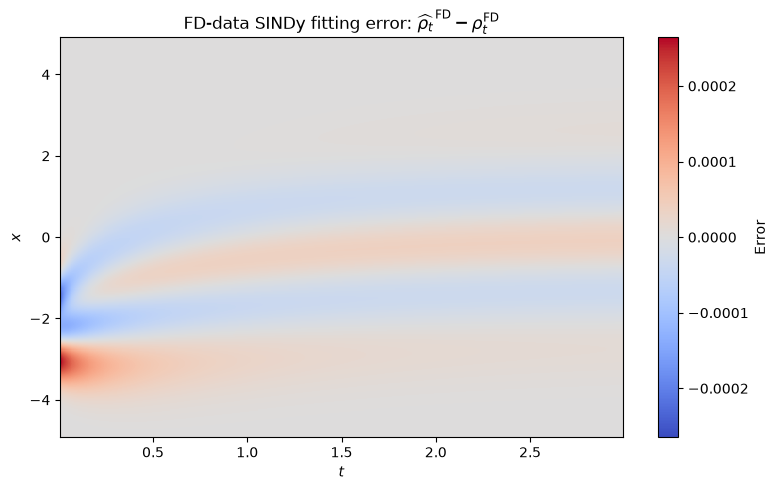

In [24]:
# ============================================================
# 2.12 FD-data heatmap 1: SINDy fitting error
# ============================================================

# prediction minus the numerical target used by SINDy
error_fit_fd_field = (
    rho_t_hat_fd_interior
    - rho_t_fd_interior
)

plot_error_heatmap(
    t_fd[time_slice_fd],
    x_fd[space_slice_fd],
    error_fit_fd_field,
    title=(
        r"FD-data SINDy fitting error: "
        r"$\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{FD}}$"
    ),
)


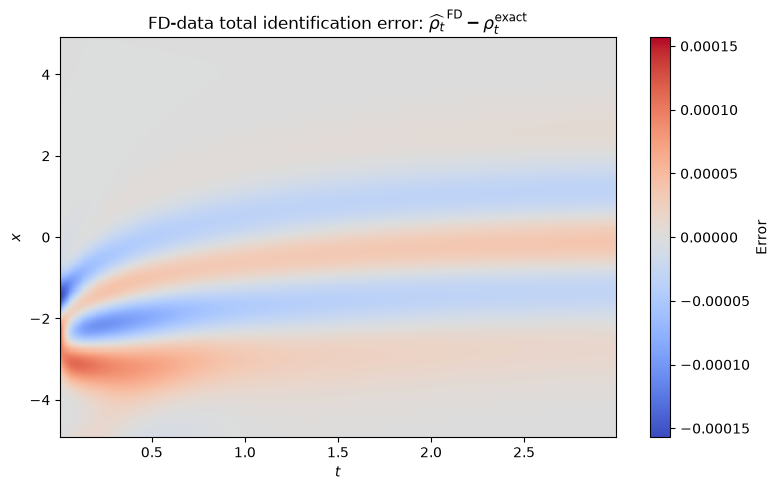

In [25]:
# ============================================================
# 2.13 FD-data heatmap 2: total error relative to exact dynamics
# ============================================================

# prediction minus the analytical reference
error_total_fd_field = (
    rho_t_hat_fd_interior
    - rho_t_exact_fd_interior
)

plot_error_heatmap(
    t_fd[time_slice_fd],
    x_fd[space_slice_fd],
    error_total_fd_field,
    title=(
        r"FD-data total identification error: "
        r"$\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{exact}}$"
    ),
)


## Interpretation of the three FD errors

The three relative errors separate the complete pipeline:

$$
\rho_t^{\mathrm{FD}}-\rho_t^{\mathrm{exact}}
$$
measures the discrepancy already present before sparse regression;

$$
\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{FD}}
$$
measures how accurately SINDy fits its numerical target; and

$$
\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{exact}}
$$
is the final end-to-end identification error.

Pointwise, the signed errors satisfy

$$
\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{exact}}
=
\left(\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{FD}}\right)
+
\left(\rho_t^{\mathrm{FD}}-\rho_t^{\mathrm{exact}}\right).
$$

Their norms do not generally add because the two component error fields may partially cancel.


# EM OU density

For EM-generated data, the complete pipeline is
$$ X^{\mathrm{EM}} \xrightarrow{\text{histogram}} \rho^{\mathrm{EM}} \xrightarrow{\text{numerical } \partial_t} \rho_t^{\mathrm{EM}}  \xrightarrow{\text{SINDy}} \widehat{\rho_t}^{\mathrm{EM}}$$

In [26]:
# ============================================================
# 3.1 Import the reusable EM solver
# ============================================================

import ou_em

importlib.reload(ou_em)
solve_ou_em = ou_em.solve_ou_em

In [27]:
# ============================================================
# 3.2 EM resolution and saved data times
# ============================================================

# Number of spatial intervals used by the histogram density
Nx_em = 100

# Number of saved time intervals supplied to SINDy
Nt_data_em = 300

# Number of internal Euler-Maruyama steps
Nt_internal_em = 6000

# Number of Monte Carlo sample paths
num_paths_em = 60000

if Nt_internal_em % Nt_data_em != 0:
    raise ValueError(
        "Nt_internal_em must be divisible by Nt_data_em so every "
        "saved time lies on the internal EM time grid."
    )

save_times_em = np.linspace(
    0.0,
    T_final,
    Nt_data_em + 1,
)

print("Number of saved times:       ", save_times_em.size)
print("Internal EM time step:       ", T_final / Nt_internal_em)
print("Saved-density time spacing:  ", T_final / Nt_data_em)
print("Number of Monte Carlo paths: ", num_paths_em)


Number of saved times:        301
Internal EM time step:        0.0005
Saved-density time spacing:   0.01
Number of Monte Carlo paths:  60000


In [28]:
# ============================================================
# 3.3 Generate EM density snapshots
# ============================================================

em_solution = solve_ou_em(
    num_paths=num_paths_em,
    N_em=Nt_internal_em,
    Nx=Nx_em,
    k=kappa,
    D=D,
    x_L=x_L,
    x_R=x_R,
    m0=m0,
    s0=s0,
    T=T_final,
    save_times=save_times_em,
    seed=319,
    store_particles=False,
)


In [29]:
# ============================================================
# 3.4 Convert the EM snapshots into rho_em(x,t)
# ============================================================

x_em = np.asarray(
    em_solution["x"],
    dtype=float,
)

t_em = np.array(
    sorted(em_solution["snapshots"].keys()),
    dtype=float,
)

rho_em = np.column_stack([
    em_solution["snapshots"][saved_time]
    for saved_time in t_em
])

dx_em = float(em_solution["dx"])
dt_internal_em = float(em_solution["dt_em"])
dt_data_em = float(t_em[1] - t_em[0])

X_em, Time_em = np.meshgrid(
    x_em,
    t_em,
    indexing="ij",
)

if rho_em.shape != X_em.shape:
    raise ValueError(
        f"rho_em has shape {rho_em.shape}, "
        f"but the EM coordinate grid has shape {X_em.shape}."
    )

# Independent analytical references evaluated on the EM grid
rho_exact_em_grid = exact_ou_density(
    X_em,
    Time_em,
    kappa,
    D,
    m0,
    s0,
)

rho_t_exact_em_grid = exact_ou_time_derivative(
    X_em,
    Time_em,
    kappa,
    D,
    m0,
    s0,
)

print("rho_em shape:", rho_em.shape)
print("x spacing:    ", dx_em)
print("saved dt:     ", dt_data_em)


rho_em shape: (101, 301)
x spacing:     0.09999999999999964
saved dt:      0.01


Minimum mass inside domain: 0.9999666666666668
Maximum mass inside domain: 1.0000000000000004
Minimum density:            0.0
Maximum density:            0.8029999999999993


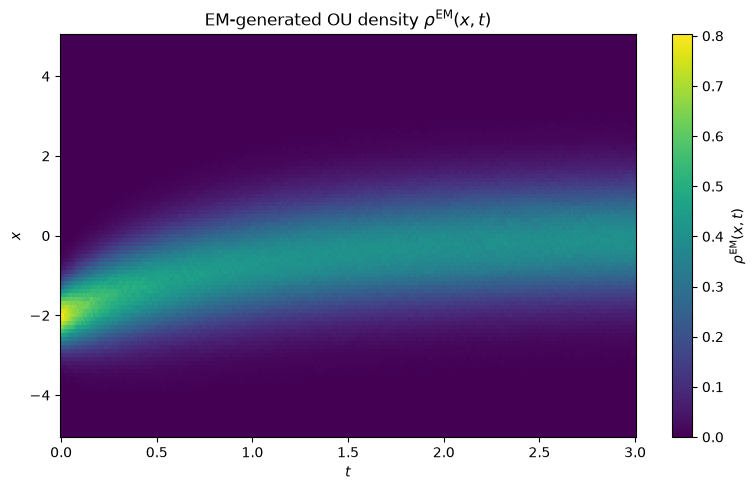

In [30]:
# ============================================================
# 3.5 Check the EM-generated density
# ============================================================

bin_widths_em = np.asarray(em_solution["bin_widths"])

mass_em = np.sum(
    rho_em * bin_widths_em[:, None],
    axis=0,
)

print("Minimum mass inside domain:", mass_em.min())
print("Maximum mass inside domain:", mass_em.max())
print("Minimum density:           ", rho_em.min())
print("Maximum density:           ", rho_em.max())

fig, ax = plt.subplots(figsize=(8, 5))

plot = ax.pcolormesh(
    t_em,
    x_em,
    rho_em,
    shading="auto",
)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x$")
ax.set_title(r"EM-generated OU density $\rho^{\mathrm{EM}}(x,t)$")

fig.colorbar(
    plot,
    ax=ax,
    label=r"$\rho^{\mathrm{EM}}(x,t)$",
)

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# 3.6 Pointwise numerical derivatives computed from rho_em
#     (used only by the ordinary, non-weak SINDy comparison)
# ============================================================

Dt_em_data = ps.FiniteDifference(
    d=1,
    axis=1,
    order=4,
)

Dx_em_data = ps.FiniteDifference(
    d=1,
    axis=0,
    order=4,
)

Dxx_em_data = ps.FiniteDifference(
    d=2,
    axis=0,
    order=4,
)

Dxxx_em_data = ps.FiniteDifference(
    d=3,
    axis=0,
    order=4,
)

# Numerical time derivative used by ordinary SINDy
rho_t_em = Dt_em_data(rho_em, t_em)

# Numerical spatial derivatives used by the ordinary SINDy library
rho_x_em = Dx_em_data(rho_em, x_em)
rho_xx_em = Dxx_em_data(rho_em, x_em)
rho_xxx_em = Dxxx_em_data(rho_em, x_em)

# Conservative drift candidates
d_x_xrho_em = Dx_em_data(X_em * rho_em, x_em)
d_x_x2rho_em = Dx_em_data(X_em**2 * rho_em, x_em)

print("rho_t_em shape:", rho_t_em.shape)


rho_t_em shape: (101, 301)


In [32]:
# ============================================================
# 3.7 Candidate library for ordinary EM-density SINDy
# ============================================================

candidate_fields_em = {
    "rho": rho_em,
    "rho_x": rho_x_em,
    "d_x(x rho)": d_x_xrho_em,
    "d_x(x^2 rho)": d_x_x2rho_em,
    "rho_xx": rho_xx_em,
    "rho_xxx": rho_xxx_em,
}

feature_names_em = list(candidate_fields_em.keys())

true_coefficients_em = np.array([
    0.0,       # rho
    0.0,       # rho_x
    kappa,     # d_x(x rho)
    0.0,       # d_x(x^2 rho)
    D,         # rho_xx
    0.0,       # rho_xxx
])


In [33]:
# ============================================================
# 3.8 Interior fitting region and ordinary sparse regression
# ============================================================

space_slice_em = slice(4, -4)
time_slice_em = slice(2, -2)

Theta_em = np.column_stack([
    field[space_slice_em, time_slice_em].ravel()
    for field in candidate_fields_em.values()
])

rho_t_em_vector = rho_t_em[
    space_slice_em,
    time_slice_em,
].ravel().reshape(-1, 1)

optimizer_em = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,
    max_iter=50,
    normalize_columns=True,
)

optimizer_em.fit(
    Theta_em,
    rho_t_em_vector,
)

coefficients_em = optimizer_em.coef_.reshape(-1)

print("Theta_em shape:       ", Theta_em.shape)
print("rho_t_em target shape:", rho_t_em_vector.shape)


Theta_em shape:        (27621, 6)
rho_t_em target shape: (27621, 1)


In [34]:
# ============================================================
# 3.9 Identified EM-data coefficients and PDE
# ============================================================

coefficient_table_em = pd.DataFrame({
    "Candidate term": feature_names_em,
    "Identified coefficient": coefficients_em,
    "True coefficient": true_coefficients_em,
    "Absolute error": np.abs(
        coefficients_em - true_coefficients_em
    ),
})

display(
    coefficient_table_em.style.format({
        "Identified coefficient": "{:.6f}",
        "True coefficient": "{:.6f}",
        "Absolute error": "{:.3e}",
    }).set_caption("SINDy coefficients from EM histogram density")
)

print_identified_equation(
    feature_names_em,
    coefficients_em,
)

,Candidate term,Identified coefficient,True coefficient,Absolute error
0,rho,-0.218370,0.000000,2.184e-01
1,rho_x,-0.686853,0.000000,6.869e-01
2,d_x(x rho),0.314546,1.000000,6.855e-01
3,d_x(x^2 rho),0.104459,0.000000,1.045e-01
4,rho_xx,0.007481,1.000000,9.925e-01
5,rho_xxx,-0.003177,0.000000,3.177e-03


True Fokker–Planck equation:
rho_t = 1.000000 d_x(x rho) + 1.000000 rho_xx

Identified Fokker–Planck equation:
rho_t = (-0.218370) rho (-0.686853) rho_x (+0.314546) d_x(x rho) (+0.104459) d_x(x^2 rho) (+0.007481) rho_xx (-0.003177) rho_xxx


## 4. Weak SINDy for the EM density

Write the OU Fokker--Planck equation in conservative form as

$$
\rho_t = \kappa\,\partial_x q + D\rho_{xx},
\qquad q(x,t)=x\rho(x,t).
$$

For every randomly sampled space--time subdomain $\Omega_k$, PySINDy uses a test function $\phi_k$ that vanishes at the boundary of that **local subdomain**. Integration by parts gives

$$
-\int_{\Omega_k}\rho\,(\phi_k)_t
=
-\kappa\int_{\Omega_k}q\,(\phi_k)_x
+
D\int_{\Omega_k}\rho\,(\phi_k)_{xx}.
$$

Therefore no pointwise numerical approximation of $\rho_t$, $q_x$ or $\rho_{xx}$ is required in this section. The weak library performs the integrations and transfers derivatives from the noisy histogram density onto the smooth test functions.

The field $q=x\rho$ is supplied as a **control field**. This is important: the state has only one component, $\rho$, so PySINDy fits only the equation for $\rho_t$ rather than also trying to fit an artificial equation for the coordinate $x$.

The weak-form parameters in this section provide one preliminary baseline.
A systematic comparison of $K$, subdomain size, and candidate-library size
is carried out in `week_7_em.ipynb`.

In [35]:
# ============================================================
# 4.1 Space-time grid, state field and conservative-flux field
# ============================================================

# WeakPDELibrary expects the final axis of the grid to contain
# the coordinates.  The resulting shape is (Nx + 1, Nt + 1, 2).
XT_em = np.stack(
    (X_em, Time_em),
    axis=-1,
)

# One dynamical state: rho(x,t)
rho_state_weak_em = rho_em[..., np.newaxis]

# One control field: q(x,t) = x rho(x,t)
xrho_control_weak_em = (
    X_em * rho_em
)[..., np.newaxis]

if rho_state_weak_em.shape[:-1] != XT_em.shape[:-1]:
    raise ValueError("rho_state_weak_em and XT_em use different grids.")

if xrho_control_weak_em.shape != rho_state_weak_em.shape:
    raise ValueError("The state and control fields must have matching shapes.")

print("XT_em shape:                 ", XT_em.shape)
print("rho_state_weak_em shape:     ", rho_state_weak_em.shape)
print("xrho_control_weak_em shape:  ", xrho_control_weak_em.shape)


XT_em shape:                  (101, 301, 2)
rho_state_weak_em shape:      (101, 301, 1)
xrho_control_weak_em shape:   (101, 301, 1)


In [36]:
# ============================================================
# 4.2 Construct the weak PDE library
# ============================================================

# K is the number of randomly sampled space-time subdomains.
K_weak_em = 1000

# H_xt contains the HALF-width of each subdomain in the
# spatial and temporal directions.  These values reproduce
# the library default L_xt / 20 explicitly.
H_xt_weak_em = np.array([
    (x_em[-1] - x_em[0]) / 20.0,
    (t_em[-1] - t_em[0]) / 20.0,
])

# The random subdomain centres are selected when the library is
# CONSTRUCTED, so the seed must be set before WeakPDELibrary(...).
np.random.seed(319)

weak_library_em = ps.WeakPDELibrary(
    # IdentityLibrary supplies the non-derivative distractor terms
    # rho and xrho.  WeakPDELibrary then adds first and second
    # spatial derivatives of both input fields.
    function_library=ps.IdentityLibrary(),
    derivative_order=2,
    spatiotemporal_grid=XT_em,
    include_bias=False,
    include_interaction=False,
    K=K_weak_em,
    H_xt=H_xt_weak_em,
    p=4,
)

print("K:                    ", K_weak_em)
print("H_xt (half-widths):   ", H_xt_weak_em)
print("Full subdomain widths:", 2.0 * H_xt_weak_em)


K:                     1000
H_xt (half-widths):    [0.5  0.15]
Full subdomain widths: [1.  0.3]


In [37]:
# ============================================================
# 4.3 Fit the weak-form sparse model
# ============================================================

optimizer_weak_em = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,
    max_iter=100,
    normalize_columns=True,
)

model_weak_em = ps.SINDy(
    feature_library=weak_library_em,
    optimizer=optimizer_weak_em,
)

# Because x_dot is not supplied, WeakPDELibrary constructs the
# integrated weak target from rho_state_weak_em.  The control field
# is concatenated only afterwards when the candidate library is built.
model_weak_em.fit(
    rho_state_weak_em,
    t=t_em,
    u=xrho_control_weak_em,
    feature_names=["rho", "xrho"],
)

weak_feature_names_em = model_weak_em.get_feature_names()
weak_coefficients_em = model_weak_em.coefficients().reshape(-1)

print("Weak regression matrix shape:", optimizer_weak_em.Theta_.shape)
print("Weak target shape:           ", optimizer_weak_em.coef_.shape[0], "equation")
print("Candidate terms:")
for name in weak_feature_names_em:
    print("  ", name)


Weak regression matrix shape: (1000, 6)
Weak target shape:            1 equation
Candidate terms:
   rho
   xrho
   rho_1
   xrho_1
   rho_11
   xrho_11


In [38]:
# ============================================================
# 4.4 Coefficient table and identified conservative PDE
# ============================================================

# With feature_names=["rho", "xrho"], the important terms are
#     xrho_1  = d_x(x rho),
#     rho_11  = rho_xx.
# The exact OU coefficients are kappa and D, respectively.
weak_true_map_em = {
    "xrho_1": kappa,
    "rho_11": D,
}

weak_true_coefficients_em = np.array([
    weak_true_map_em.get(name, 0.0)
    for name in weak_feature_names_em
])

weak_coefficient_table_em = pd.DataFrame({
    "Candidate term": weak_feature_names_em,
    "Identified coefficient": weak_coefficients_em,
    "True coefficient": weak_true_coefficients_em,
    "Absolute error": np.abs(
        weak_coefficients_em - weak_true_coefficients_em
    ),
})

display(
    weak_coefficient_table_em.style.format({
        "Identified coefficient": "{:.6f}",
        "True coefficient": "{:.6f}",
        "Absolute error": "{:.3e}",
    }).set_caption("Weak-SINDy coefficients from EM histogram density")
)

print("True conservative OU equation:")
print("rho_t = kappa d_x(x rho) + D rho_xx")
print("\nIdentified weak-form equation:")
print_identified_equation(
    weak_feature_names_em,
    weak_coefficients_em,
)


,Candidate term,Identified coefficient,True coefficient,Absolute error
0,rho,0.000000,0.000000,0.000e+00
1,xrho,0.000000,0.000000,0.000e+00
2,rho_1,0.000000,0.000000,0.000e+00
3,xrho_1,0.965086,1.000000,3.491e-02
4,rho_11,0.961461,1.000000,3.854e-02
5,xrho_11,0.000000,0.000000,0.000e+00


True conservative OU equation:
rho_t = kappa d_x(x rho) + D rho_xx

Identified weak-form equation:
True Fokker–Planck equation:
rho_t = 1.000000 d_x(x rho) + 1.000000 rho_xx

Identified Fokker–Planck equation:
rho_t = (+0.965086) xrho_1 (+0.961461) rho_11


In [39]:
# ============================================================
# 4.5 Weak-regression residual
# ============================================================

# convert_u_dot_integral returns the K weak equations on the LHS,
# i.e. the integrated version of rho_t.
weak_target_em = weak_library_em.convert_u_dot_integral(
    rho_state_weak_em
)

weak_prediction_em = model_weak_em.predict(
    rho_state_weak_em,
    u=xrho_control_weak_em,
)

weak_relative_residual_em = relative_l2_error(
    weak_prediction_em,
    weak_target_em,
)

print("Weak target shape:     ", weak_target_em.shape)
print("Weak prediction shape: ", weak_prediction_em.shape)
print(
    "Relative L2 residual in weak regression:",
    f"{weak_relative_residual_em:.6e}",
)

# This residual lives in the K-dimensional weak-integral system.
# It is not a pointwise heatmap error on the original (x,t) grid.


Weak target shape:      (1000, 1)
Weak prediction shape:  (1000, 1)
Relative L2 residual in weak regression: 2.321562e-01


In [40]:
def extract_coefficient(names, coefficients, target_name):
    if target_name not in names:
        return np.nan
    return coefficients[names.index(target_name)]


def support_is_correct(names, coefficients, true_support, tolerance=1e-10):
    identified_support = {
        name
        for name, coefficient in zip(names, coefficients)
        if abs(coefficient) > tolerance
    }
    return identified_support == set(true_support)


baseline_summary = pd.DataFrame([
    {
        "Data source": "Exact density",
        "Method": "Pointwise SINDy",
        "Correct support": support_is_correct(
            feature_names,
            coefficients,
            {"d_x(x rho)", "rho_xx"},
        ),
        "Identified kappa": extract_coefficient(
            feature_names,
            coefficients,
            "d_x(x rho)",
        ),
        "Identified D": extract_coefficient(
            feature_names,
            coefficients,
            "rho_xx",
        ),
    },
    {
        "Data source": "FD density",
        "Method": "Pointwise SINDy",
        "Correct support": support_is_correct(
            feature_names_fd,
            coefficients_fd,
            {"d_x(x rho)", "rho_xx"},
        ),
        "Identified kappa": extract_coefficient(
            feature_names_fd,
            coefficients_fd,
            "d_x(x rho)",
        ),
        "Identified D": extract_coefficient(
            feature_names_fd,
            coefficients_fd,
            "rho_xx",
        ),
    },
    {
        "Data source": "EM histogram",
        "Method": "Pointwise SINDy",
        "Correct support": support_is_correct(
            feature_names_em,
            coefficients_em,
            {"d_x(x rho)", "rho_xx"},
        ),
        "Identified kappa": extract_coefficient(
            feature_names_em,
            coefficients_em,
            "d_x(x rho)",
        ),
        "Identified D": extract_coefficient(
            feature_names_em,
            coefficients_em,
            "rho_xx",
        ),
    },
    {
        "Data source": "EM histogram",
        "Method": "Weak SINDy",
        "Correct support": support_is_correct(
            weak_feature_names_em,
            weak_coefficients_em,
            {"xrho_1", "rho_11"},
        ),
        "Identified kappa": extract_coefficient(
            weak_feature_names_em,
            weak_coefficients_em,
            "xrho_1",
        ),
        "Identified D": extract_coefficient(
            weak_feature_names_em,
            weak_coefficients_em,
            "rho_11",
        ),
    },
])

display(
    baseline_summary.style.format({
        "Identified kappa": "{:.6f}",
        "Identified D": "{:.6f}",
    }).set_caption("Baseline identification summary")
)

,Data source,Method,Correct support,Identified kappa,Identified D
0,Exact density,Pointwise SINDy,True,1.000000,1.000000
1,FD density,Pointwise SINDy,True,0.999918,0.999975
2,EM histogram,Pointwise SINDy,False,0.314546,0.007481
3,EM histogram,Weak SINDy,True,0.965086,0.961461


## Conclusion

Pointwise SINDy recovers the correct Ornstein–Uhlenbeck operator from the
smooth exact and finite-difference densities. The identified coefficients
are close to the physical values $\kappa=D=1$.

For the Euler–Maruyama histogram density, pointwise numerical differentiation
amplifies bin-to-bin sampling fluctuations. The resulting regression retains
several spurious terms and does not recover the correct PDE.

Weak SINDy transfers derivatives from the noisy density to smooth test
functions and recovers the conservative two-term support from the same
trajectory-based density.

This experiment establishes the main motivation for the systematic weak-form
parameter study in Week 7. The weak residual is defined in the integrated
$K$-dimensional regression system and should not be compared directly with
the pointwise derivative errors.